<a href="https://colab.research.google.com/github/halimAhtasham/Algorithm_Exercise/blob/main/EDA_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
DATASET_PATH = "/content/drive/MyDrive/Datasets/customer_data.csv"

In [5]:
data = pd.read_csv(DATASET_PATH)

In [6]:
data.head()

,customer_id,gender,age,payment_method
0,C241288,Female,28.0,Credit Card
1,C111565,Male,21.0,Debit Card
2,C266599,Male,20.0,Cash
3,C988172,Female,66.0,Credit Card
4,C189076,Female,53.0,Cash


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     99457 non-null  object 
 1   gender          99457 non-null  object 
 2   age             99338 non-null  float64
 3   payment_method  99457 non-null  object 
dtypes: float64(1), object(3)
memory usage: 3.0+ MB


In [8]:
data.shape

(99457, 4)

In [9]:
data.columns

Index(['customer_id', 'gender', 'age', 'payment_method'], dtype='object')

In [10]:
titanic = "/content/drive/MyDrive/Datasets/Titanic-Dataset.csv"

In [11]:
df_titanic = pd.read_csv(titanic)

In [12]:
import numpy as np

In [13]:
df_titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [14]:
df_titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [15]:
df_titanic.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
886,False
887,False
888,False
889,False


In [16]:
df_titanic.duplicated().sum()

np.int64(0)

In [17]:
cat_col = [col for col in df_titanic.columns if df_titanic[col].dtype == "object"]
num_col = [col for col in df_titanic.columns if df_titanic[col].dtype != 'object']

In [18]:
print("Categorical Columns: ", cat_col)
print("Numerical Columns: ", num_col)

Categorical Columns:  ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']
Numerical Columns:  ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


In [19]:
df_titanic[cat_col].nunique()

,0
Name,891
Sex,2
Ticket,681
Cabin,147
Embarked,3


In [20]:
round((df_titanic.isnull().sum() / len(df_titanic) ) * 100 ,2)

,0
PassengerId,0.00
Survived,0.00
Pclass,0.00
Name,0.00
Sex,0.00
Age,19.87
SibSp,0.00
Parch,0.00
Ticket,0.00
Fare,0.00


In [21]:
df1 = df_titanic.drop(columns=['Name', 'Ticket', 'Cabin'])

In [22]:
df1.dropna(subset = ['Embarked'], inplace=True)

In [23]:
df1['Age'] = df1['Age'].fillna(df1['Age'].mean())

In [24]:
import matplotlib.pyplot as plt

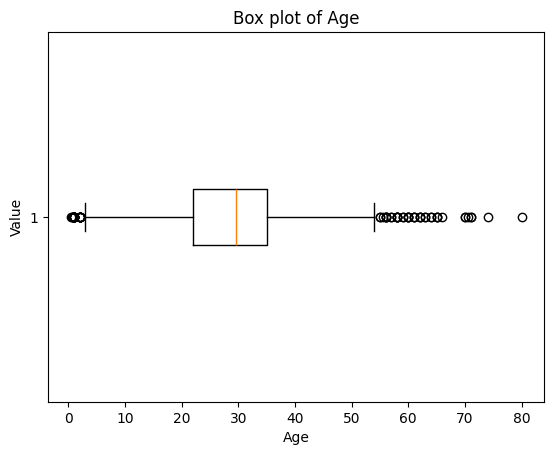

In [25]:
plt.boxplot(df1['Age'], vert=False)
plt.xlabel("Age")
plt.ylabel("Value")
plt.title("Box plot of Age")
plt.show()

In [26]:
mean = df1['Age'].mean()
std = df1['Age'].std()

lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

In [27]:
df2 = df1[(df1['Age'] >= lower_bound) & (df1['Age']  <= upper_bound)]

In [28]:
print(df2.head())

   PassengerId  Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0            1         0       3    male  22.0      1      0   7.2500        S
1            2         1       1  female  38.0      1      0  71.2833        C
2            3         1       3  female  26.0      0      0   7.9250        S
3            4         1       1  female  35.0      1      0  53.1000        S
4            5         0       3    male  35.0      0      0   8.0500        S


In [29]:
df2.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [30]:
df2.duplicated().sum()

np.int64(0)

In [31]:
df3 = df2.fillna(df2['Age'].mean())

In [32]:
df3.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0


In [33]:
print(lower_bound)
print(upper_bound)

3.705400107925648
55.578785285332785


In [34]:
mean = df3['Age'].mean()
std = df3['Age'].std()

lower_bound = mean - 2 * std
upper_bound = mean + 2 * std

print(lower_bound)
print(upper_bound)

df4 = df3[(df3['Age'] >= lower_bound) & (df3['Age'] <= upper_bound)]

8.978989004171481
49.30395961288911


In [35]:
df3.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0
Embarked,0
